--- 1. 模型参数 ---
权重向量 w: [9.99680000e-01 3.33066907e-16]
偏置项 b: -4.998506666666668
分类超平面方程为: 1.00*x1 + 0.00*x2 + -5.00 = 0

--- 2. 支持向量 ---
计算得到的支持向量坐标为:
[[4. 4.]
 [4. 2.]
 [6. 3.]] 

--- 3. 预测新样本 ---
样本 x9 [3 4]: wx+b 的值为 -2.00, 预测类别为 -1
样本 x10 [7 4]: wx+b 的值为 2.00, 预测类别为 1
样本 x11 [5 5]: wx+b 的值为 -0.00, 预测类别为 -1
(注：x11 的 wx+b 正好为 0，位于决策边界上，算法默认将其归类为 1)


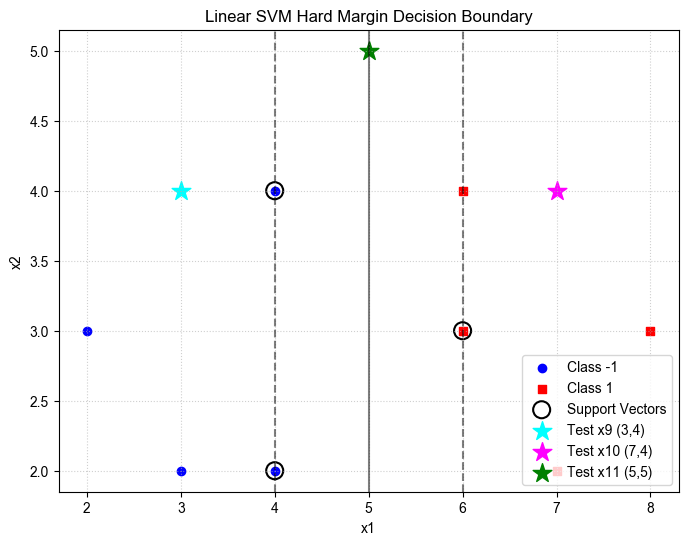

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
# 或者尝试：plt.rcParams['font.sans-serif'] = ['Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 定义训练数据和测试数据
# ==========================================
X_train = np.array([
    [2, 3], [3, 2], [4, 4], [4, 2],  # y = -1 的样本
    [6, 4], [6, 3], [7, 2], [8, 3]   # y = 1 的样本
])
y_train = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

X_test = np.array([
    [3, 4],   # x9
    [7, 4],   # x10
    [5, 5]    # x11
])

# ==========================================
# 2. 训练硬间隔线性支持向量机模型
# ==========================================
# C 设置得非常大，代表对误差的容忍度极低，从而模拟硬间隔
model = svm.SVC(kernel='linear', C=1e5)
model.fit(X_train, y_train)

# 获取模型参数 w 和 b
w = model.coef_[0]
b = model.intercept_[0]
print("--- 1. 模型参数 ---")
print(f"权重向量 w: {w}")
print(f"偏置项 b: {b}")
print(f"分类超平面方程为: {w[0]:.2f}*x1 + {w[1]:.2f}*x2 + {b:.2f} = 0\n")

# ==========================================
# 3. 找出支持向量
# ==========================================
support_vectors = model.support_vectors_
print("--- 2. 支持向量 ---")
print("计算得到的支持向量坐标为:")
print(support_vectors, "\n")

# ==========================================
# 4. 对新样本进行预测
# ==========================================
predictions = model.predict(X_test)
decision_values = model.decision_function(X_test) # 计算 wx+b 的值

print("--- 3. 预测新样本 ---")
for i, test_point in enumerate(X_test):
    print(f"样本 x{i+9} {test_point}: wx+b 的值为 {decision_values[i]:.2f}, 预测类别为 {predictions[i]}")
print("(注：x11 的 wx+b 正好为 0，位于决策边界上，算法默认将其归类为 1)")

# ==========================================
# 5. 可视化绘图
# ==========================================
plt.figure(figsize=(8, 6))

# 画出训练数据点
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], color='blue', marker='o', label='Class -1')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', marker='s', label='Class 1')

# 圈出支持向量
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')

# 画出测试数据点
plt.scatter(X_test[0, 0], X_test[0, 1], color='cyan', marker='*', s=200, label='Test x9 (3,4)')
plt.scatter(X_test[1, 0], X_test[1, 1], color='magenta', marker='*', s=200, label='Test x10 (7,4)')
plt.scatter(X_test[2, 0], X_test[2, 1], color='green', marker='*', s=200, label='Test x11 (5,5)')

# 绘制决策边界和间隔边界
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# 创建网格来评估模型
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# 画出决策边界 (wx+b=0) 和 两个间隔边界 (wx+b=-1, wx+b=1)
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Linear SVM Hard Margin Decision Boundary')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()